In [1]:
import pandas as pd
import re
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse.linalg import svds
import numpy as np
import matplotlib.pyplot as plt

In [2]:


df = pd.read_csv("wiki_movie_plots_deduped.csv")

GENEROS = ["drama", "comedy", "horror", "action", "romance"]

df_filtrado = (
    df[df["Genre"].isin(GENEROS)]
    .groupby("Genre")
    .apply(lambda x: x.sample(100, random_state=42))
    .reset_index(drop=True)
)

df_corpus = df_filtrado[["Title", "Genre", "Plot"]].dropna().reset_index(drop=True)

print(f"Total documentos: {len(df_corpus)}")
print(df_corpus["Genre"].value_counts())
print()
print("Ejemplo de Plot:")
print(df_corpus["Plot"].iloc[0][:400])

Total documentos: 500
Genre
action     100
comedy     100
drama      100
horror     100
romance    100
Name: count, dtype: int64

Ejemplo de Plot:
Top flight Le Mans racing driver Michael Delaney spots former rival Piero Belgetti's widow Lisa buying flowers in the days before the 1971 race; he then drives to the scene of the accident which killed her husband the previous year. He has a flashback of Belgetti losing control of his Ferrari, forcing him to crash as well.
Like many others, Lisa appears to feel Delaney was responsible, at least i


C:\Users\alonso\AppData\Local\Temp\ipykernel_17164\2211817020.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(100, random_state=42))


## P1 — Corpus: Wikipedia Movie Plots

| | |
|---|---|
| **Fuente** | wiki_movie_plots_deduped.csv — Wikipedia Movie Plots |
| **Dataset completo** | 34.886 películas (1901–2017) |
| **Documentos usados** | 500 (100 por género, muestra balanceada) |
| **Géneros seleccionados** | drama, comedy, horror, action, romance |

El corpus consiste en descripciones de tramas de películas extraídas de Wikipedia.
Se eligió porque cada documento tiene volumen de texto suficiente para LSA,
los géneros funcionan como etiquetas naturales para validar los clusters,
y el dataset es público y reproducible.

## P2 — Hipótesis Inicial

Esperamos que las primeras componentes del SVD capturen diferencias temáticas entre los géneros cinematográficos. Anticipamos dos formas, no excluyentes, en las que esto podría reflejarse:

- **Distribución espacial:** las películas se agruparían en regiones distintas del espacio reducido según su género.
- **Componentes temáticas:** cada uno de los primeros 5 componentes representaría de alguna manera a un género específico.

In [3]:
nlp = spacy.load("en_core_web_sm")

EXTRA_STOPS = {"film", "movie", "scene", "story", "character", 
               "tell", "make", "find", "come", "go", "take", "nick",
               "loomis"}

def preprocesar(texto):

    texto = re.sub(r"\[.*?\]", " ", texto)
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    doc = nlp(texto)
    tokens = [
        t.lemma_.lower() for t in doc
        if not t.is_stop
        and not t.is_punct
        and len(t.lemma_) > 2
        and t.lemma_.lower() not in EXTRA_STOPS
        and t.pos_ != "PROPN"
    ]
    return " ".join(tokens)

print("Preprocesando... esto toma 1-2 minutos")
df_corpus["plot_limpio"] = df_corpus["Plot"].apply(preprocesar)

vocab_antes = set(" ".join(df_corpus["Plot"].str.lower()).split())
vocab_despues = set(" ".join(df_corpus["plot_limpio"]).split())

print(f"\nVocabulario antes:  {len(vocab_antes):,} términos")
print(f"Vocabulario después: {len(vocab_despues):,} términos")
print(f"\nEjemplo texto limpio:")
print(df_corpus["plot_limpio"].iloc[0][:400])

Preprocesando... esto toma 1-2 minutos

Vocabulario antes:  27,566 términos
Vocabulario después: 8,407 términos

Ejemplo texto limpio:
flight race driver spot rival widow buy flower day race drive accident kill husband previous year flashback lose control force crash like appear feel responsible accident race understandably downcast work emotion awkward look place sit crowded track commissary ask join obvious tension respect hint mutual attraction hour race spin cause teammate veer track major accident momentarily distract flame 


## P3 — Preprocesamiento del texto

Antes de construir la matriz, limpiamos el texto con las siguientes decisiones:

- **Lematización:** usamos spaCy para reducir cada palabra a su forma base, 
  así *killed*, *killing* y *killer* no se tratan como palabras distintas.
- **Stopwords:** removimos las stopwords estándar de spaCy más palabras genéricas 
  del dominio como *film, movie, scene, story*, que aparecen en casi todas las 
  películas y no dicen nada útil sobre el género.
- **Nombres propios:** eliminamos tokens con POS `PROPN` para que los nombres de 
  personajes no contaminen el vocabulario.
- **TF-IDF con bigramas:** usamos `ngram_range=(1,2)` para capturar frases como 
  *serial killer* o *happy ending*, `min_df=3` para descartar términos que aparecen 
  en muy pocas películas, y `max_df=0.85` para ignorar los que aparecen en casi todas.

In [4]:
vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=3,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df_corpus["plot_limpio"])

A = X.T

print(f"Dimensión de A (término-documento): {A.shape}")
print(f"  → {A.shape[0]:,} términos (filas)")
print(f"  → {A.shape[1]} documentos (columnas)")
print(f"\nVocabulario final: {len(vectorizer.vocabulary_):,} términos")
print(f"\nUna entrada A[i,j] = peso TF-IDF del término i en el documento j.")
print(f"Valor alto → término relevante y distintivo en ese documento.")

Dimensión de A (término-documento): (4494, 500)
  → 4,494 términos (filas)
  → 500 documentos (columnas)

Vocabulario final: 4,494 términos

Una entrada A[i,j] = peso TF-IDF del término i en el documento j.
Valor alto → término relevante y distintivo en ese documento.


In [5]:
k = 50
U, sigma, Vt = svds(A, k=k)

U     = U[:, ::-1]
sigma = sigma[::-1]
Vt    = Vt[::-1, :]

print(f"Dimensiones SVD:")
print(f"  U     (términos x componentes): {U.shape}")
print(f"  sigma (valores singulares):     {sigma.shape}")
print(f"  Vt    (componentes x docs):     {Vt.shape}")
print(f"\nPrimeros 10 valores singulares:")
for i, s in enumerate(sigma[:10]):
    print(f"  σ{i+1} = {s:.4f}")

Dimensiones SVD:
  U     (términos x componentes): (4494, 50)
  sigma (valores singulares):     (50,)
  Vt    (componentes x docs):     (50, 500)

Primeros 10 valores singulares:
  σ1 = 4.9946
  σ2 = 2.4445
  σ3 = 1.9349
  σ4 = 1.8103
  σ5 = 1.7768
  σ6 = 1.7116
  σ7 = 1.6860
  σ8 = 1.6507
  σ9 = 1.6322
  σ10 = 1.6074


## P5 — Cálculo de la SVD

La descomposición A = UΣVᵀ sobre la matriz término-documento entrega tres objetos:

- **Σ (valores singulares):** miden la "importancia" de cada componente. Un valor singular grande 
  indica que esa dirección concentra mucha variación en el corpus. En nuestro caso, los primeros 
  valores singulares capturan los temas más dominantes entre los 5 géneros.

- **U (vectores singulares izquierdos):** cada columna es una dirección en el espacio de términos. 
  Los términos con mayor peso (positivo o negativo) en una columna de U son los que mejor 
  caracterizan ese tema latente.

- **Vᵀ (vectores singulares derechos):** cada fila es una dirección en el espacio de documentos. 
  Las coordenadas de un documento en esa fila indican cuánto se alinea con el tema correspondiente. 
  Documentos con coordenadas similares son semánticamente parecidos.

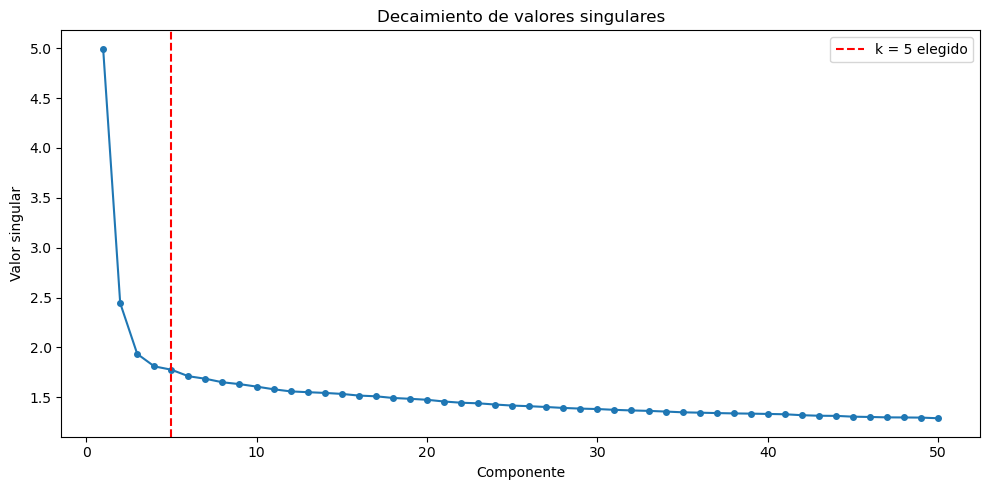

Varianza explicada acumulada:
  k=5: 30.8%
  k=6: 33.0%
  k=10: 41.1%
  k=20: 58.5%
  k=50: 100.0%


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(sigma) + 1), sigma, marker='o', markersize=4)
plt.axvline(x=5, color='red', linestyle='--', label='k = 5 elegido')
plt.xlabel("Componente")
plt.ylabel("Valor singular")
plt.title("Decaimiento de valores singulares")
plt.legend()
plt.tight_layout()
plt.savefig("valores_singulares.png", dpi=150)
plt.show()


varianza = sigma**2 / np.sum(sigma**2)
varianza_acum = np.cumsum(varianza)
print("Varianza explicada acumulada:")
for i in [5, 6, 10, 20, 50]:
    print(f"  k={i}: {varianza_acum[i-1]*100:.1f}%")

Se observa un decaimiento pronunciado en los primeros 4-5 valores singulares, seguido de una zona de decaimiento lento. Se eligió **k=5** apoyándose en dos criterios: el codo del gráfico se ubica en esa zona, y el corpus contiene exactamente 5 géneros cinematográficos. La varianza acumulada se reporta como referencia adicional (30.8% con k=5), pero no se utilizó como criterio principal de selección porque está fuera de las herramientas presentadas en el curso.

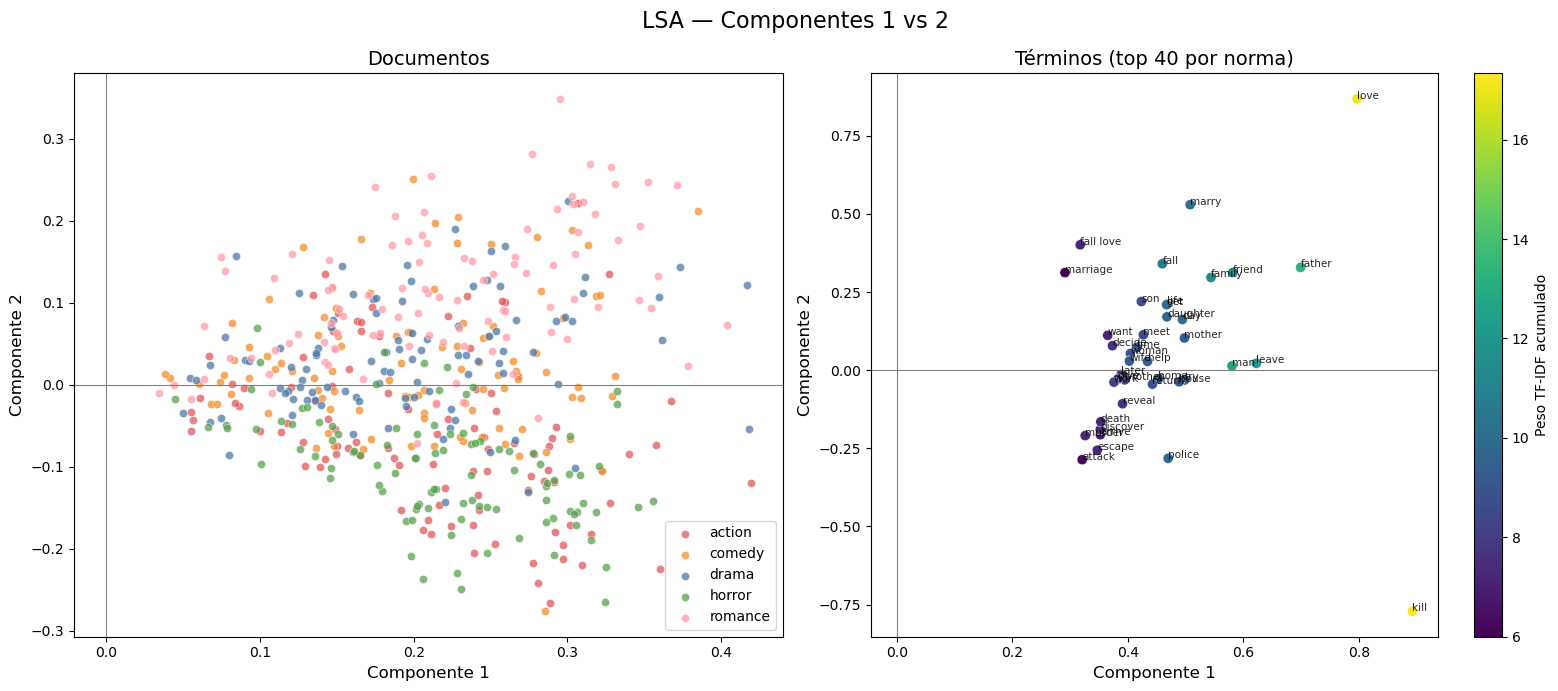

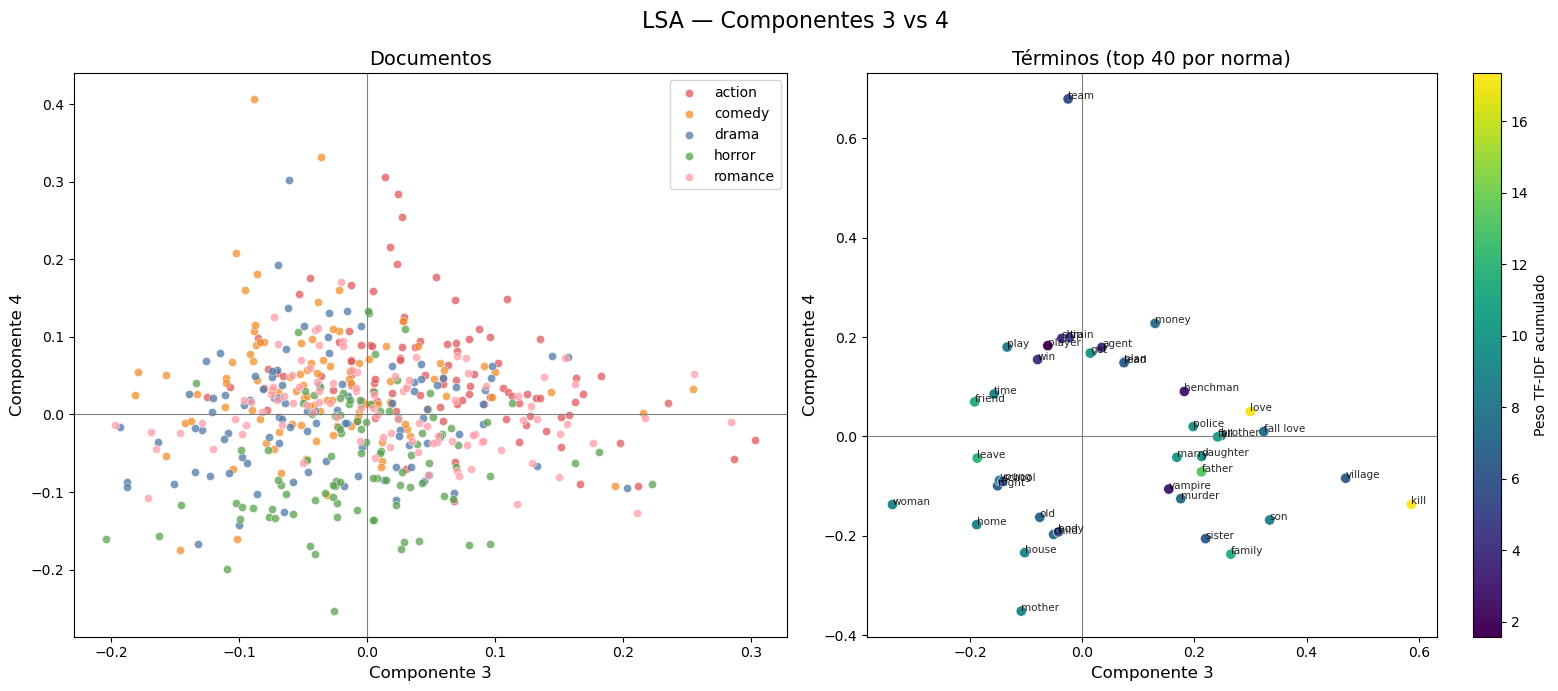

In [7]:
# P7 — Representación de documentos y términos en baja dimensión

vocabulario = vectorizer.get_feature_names_out()
freq_terminos = np.asarray(X.sum(axis=0)).ravel()  # peso total TF-IDF por término

COLORES_GENERO = {
    "action":  "#e15759",
    "comedy":  "#f28e2b",
    "drama":   "#4e79a7",
    "horror":  "#59a14f",
    "romance": "#ff9da7",
}

def coordenadas_documentos(sigma, Vt, componentes=(1, 2)):
    idx = [c - 1 for c in componentes]
    return np.diag(sigma[idx]) @ Vt[idx, :]   # (2, n_docs)

def coordenadas_terminos(U, sigma, componentes=(1, 2)):
    idx = [c - 1 for c in componentes]
    return U[:, idx] @ np.diag(sigma[idx])     # (n_terms, 2)

def graficar_lsa(sigma, Vt, U, componentes=(1, 2), n_terms=40, titulo="LSA"):
    coords_docs  = coordenadas_documentos(sigma, Vt, componentes)
    coords_terms = coordenadas_terminos(U, sigma, componentes)

    normas  = np.linalg.norm(coords_terms, axis=1)
    top_idx = np.argsort(normas)[::-1][:n_terms]
    generos = df_corpus["Genre"].values
    c1, c2  = componentes

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # — documentos coloreados por género —
    for genero, color in COLORES_GENERO.items():
        mask = generos == genero
        axes[0].scatter(
            coords_docs[0, mask], coords_docs[1, mask],
            s=35, color=color, label=genero, alpha=0.75,
            edgecolor="white", linewidth=0.4,
        )
    axes[0].axhline(0, color="gray", lw=0.8)
    axes[0].axvline(0, color="gray", lw=0.8)
    axes[0].set_title("Documentos", fontsize=14)
    axes[0].set_xlabel(f"Componente {c1}", fontsize=12)
    axes[0].set_ylabel(f"Componente {c2}", fontsize=12)
    axes[0].legend(fontsize=10)

    # — términos más relevantes —
    sc = axes[1].scatter(
        coords_terms[top_idx, 0], coords_terms[top_idx, 1],
        s=55, c=freq_terminos[top_idx], cmap="viridis",
        edgecolor="white", linewidth=0.4,
    )
    for i in top_idx:
        axes[1].annotate(
            vocabulario[i],
            (coords_terms[i, 0], coords_terms[i, 1]),
            fontsize=7.5, alpha=0.85,
        )
    axes[1].axhline(0, color="gray", lw=0.8)
    axes[1].axvline(0, color="gray", lw=0.8)
    axes[1].set_title(f"Términos (top {n_terms} por norma)", fontsize=14)
    axes[1].set_xlabel(f"Componente {c1}", fontsize=12)
    axes[1].set_ylabel(f"Componente {c2}", fontsize=12)
    fig.colorbar(sc, ax=axes[1], label="Peso TF-IDF acumulado")

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.savefig(f"lsa_comp{c1}_{c2}.png", dpi=150)
    plt.show()

graficar_lsa(sigma, Vt, U, componentes=(1, 2), titulo="LSA — Componentes 1 vs 2")
graficar_lsa(sigma, Vt, U, componentes=(3, 4), titulo="LSA — Componentes 3 vs 4")

In [8]:
# P8 — Exploración semántica
from sklearn.metrics.pairwise import cosine_similarity

k_sem = 5
D_k = (np.diag(sigma[:k_sem]) @ Vt[:k_sem, :]).T   # (500, k)  — coordenadas de documentos
T_k = U[:, :k_sem] @ np.diag(sigma[:k_sem])         # (n_terms, k) — coordenadas de términos

# 1) Términos más cargados en cada componente
# Tomamos las 14 palabras con mayor valor absoluto y las separamos por signo
print("=" * 60)
print("Ejemplo 1: ¿Qué representa cada componente?")
print("=" * 60)
for comp in range(1, 6):
    idx = comp - 1
    scores = U[:, idx]
    top14 = np.argsort(np.abs(scores))[::-1][:14]
    positivos = sorted([i for i in top14 if scores[i] > 0], key=lambda i: -scores[i])
    negativos = sorted([i for i in top14 if scores[i] < 0], key=lambda i:  scores[i])
    print(f"\nComponente {comp}  (σ = {sigma[idx]:.3f})")
    print(f"  (+)  {', '.join(vocabulario[positivos])}")
    print(f"  (-)  {', '.join(vocabulario[negativos])}")

Ejemplo 1: ¿Qué representa cada componente?

Componente 1  (σ = 4.995)
  (+)  kill, love, father, leave, friend, man, family, marry, try, mother, day, house, police, life
  (-)  

Componente 2  (σ = 2.445)
  (+)  love, marry, fall love, fall, father, friend, marriage, family, wedding
  (-)  kill, attack, police, escape, zombie

Componente 3  (σ = 1.935)
  (+)  kill, village, son, fall love, love, family, brother, fall, sister, daughter, father, police
  (-)  woman, friend

Componente 4  (σ = 1.810)
  (+)  team, money, train, ship, player, play, agent
  (-)  mother, family, house, sister, child, body, home

Componente 5  (σ = 1.777)
  (+)  love, woman, vampire, team, fall, kill
  (-)  police, money, officer, family, village, train, police officer, father


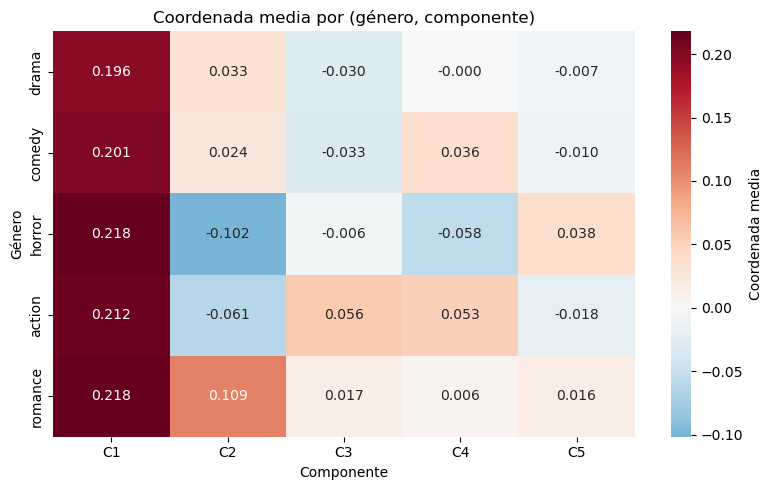

In [9]:
# Heatmap: coordenada media por (género, componente)
# Permite ver qué componente caracteriza más a cada género
import seaborn as sns

df_coords = pd.DataFrame(D_k, columns=[f"C{i+1}" for i in range(k_sem)])
df_coords["Genre"] = df_corpus["Genre"].values
mean_by_genre = df_coords.groupby("Genre")[[f"C{i+1}" for i in range(k_sem)]].mean().loc[GENEROS]

plt.figure(figsize=(8, 5))
sns.heatmap(mean_by_genre, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            cbar_kws={'label': 'Coordenada media'})
plt.title("Coordenada media por (género, componente)")
plt.xlabel("Componente")
plt.ylabel("Género")
plt.tight_layout()
plt.savefig("heatmap_genero_componente.png", dpi=150)
plt.show()

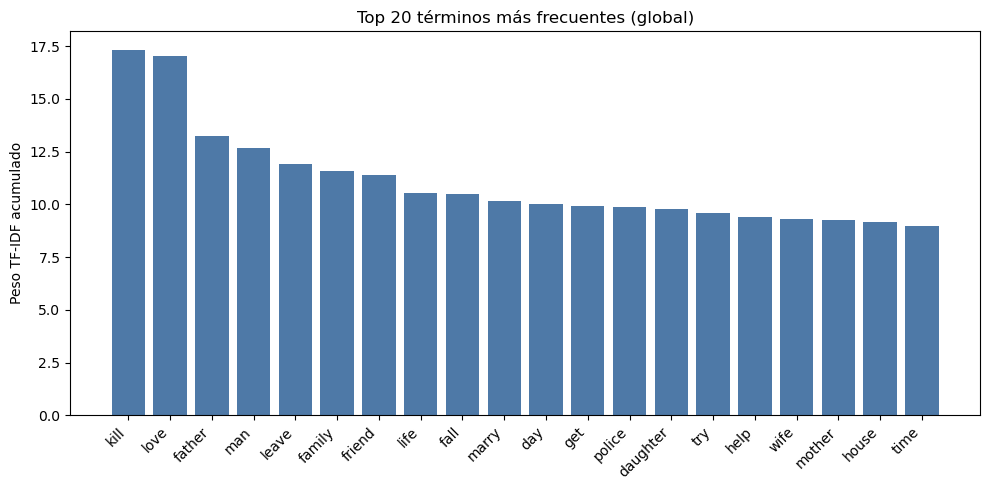

In [10]:
# Top términos globales
top_n = 20
indices_top = np.argsort(freq_terminos)[::-1][:top_n]

plt.figure(figsize=(10, 5))
plt.bar(vocabulario[indices_top], freq_terminos[indices_top], color="#4e79a7")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylabel("Peso TF-IDF acumulado")
plt.title(f"Top {top_n} términos más frecuentes (global)")
plt.tight_layout()
plt.show()

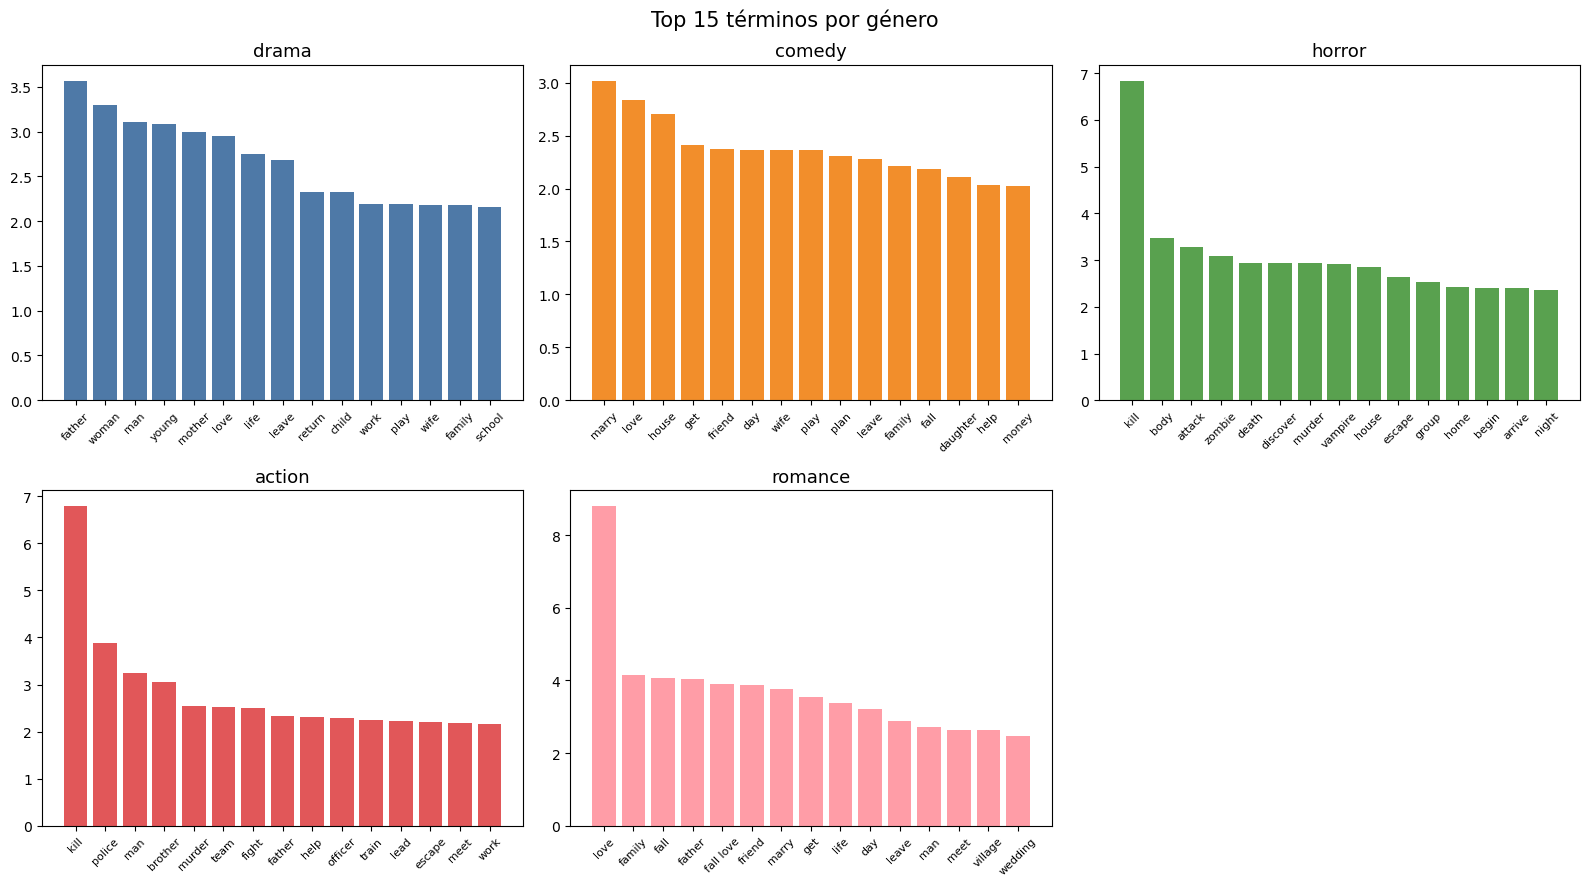

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, genero in zip(axes, GENEROS):
    mask = df_corpus["Genre"] == genero
    X_gen = X[mask.to_numpy()]
    freq_gen = np.asarray(X_gen.sum(axis=0)).ravel()
    top = np.argsort(freq_gen)[::-1][:15]

    ax.bar(vocabulario[top], freq_gen[top], color=COLORES_GENERO[genero])
    ax.set_title(genero, fontsize=13)
    ax.tick_params(axis="x", rotation=45, labelsize=8)

axes[-1].set_visible(False)   # oculta el sexto panel vacío
plt.suptitle("Top 15 términos por género", fontsize=15)
plt.tight_layout()
plt.show()

## P9 — Discusión, limitaciones y conclusiones

### Comparación con la hipótesis inicial

La hipótesis anticipaba dos formas posibles de captar diferencias entre géneros: agrupamientos espaciales por género, o un componente que representara cada género. Los resultados confirman que **sí se captan diferencias temáticas**, pero no exactamente en la forma anticipada. Las componentes no se asocian a un género en específico; más bien funcionan como **ejes que separan pares de géneros** con vocabulario distinto, especialmente de la componente 2 a la 5. La diferenciación entre géneros existe, pero ocurre a través de la comparación entre temáticas, no por asignación directa componente-género.

### Limitaciones

- **Tamaño muestral:** trabajamos con 500 películas seleccionadas de un dataset de ~35.000. Un análisis sobre el corpus completo podría mostrar separaciones más claras entre géneros y capturar subgéneros que con 100 películas por categoría no se alcanzan a ver.
- **Filtrado de nombres propios:** la regla `t.pos_ != PROPN` elimina tanto nombres de personas como nombres de lugares. Refinar el filtrado para conservar los lugares (ciudades, regiones) y descartar solo nombres de personas podría aportar información útil para diferenciar géneros.

### Conclusión

LSA con SVD permitió descubrir estructura temática latente en el corpus de tramas de películas, validando la hipótesis general de que las primeras componentes capturan diferencias entre géneros. La novedad de los resultados está en que esta captura ocurre por **separación entre pares de géneros**, no por asignación directa de componentes a géneros. LSA termina siendo una herramienta exploratoria útil para visualizar y entender la estructura temática del corpus, pero no funciona como un clasificador directo.